In [1]:
from pathlib import Path

import pandas as pd
import geopandas as gpd

from conf import config

/home/lgraff/ENTER/envs/py39/lib/python3.9/site-packages/geopandas/tools/clip.py:67: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  clipped.loc[


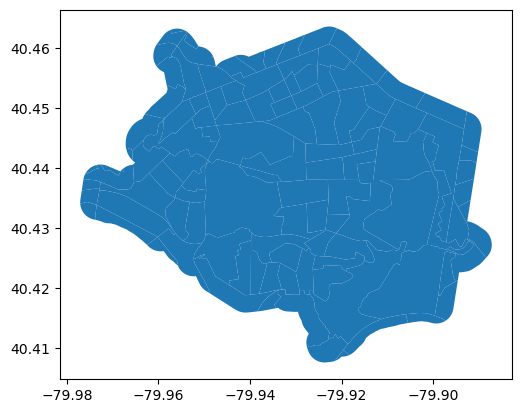

In [2]:
study_area_gdf = gpd.read_file(config['paths']['data']['study_area_out'])
study_area_gdf.to_crs(epsg=4269, inplace=True)

shapefile_path = Path().resolve() / 'data' / 'demographics' / 'raw' / 'tl_2022_42_bg' / 'tl_2022_42_bg.shp'
shape = gpd.read_file(shapefile_path, mask=study_area_gdf)  # only include blocks within study area
shape.to_crs(epsg=4269, inplace=True)
shape = gpd.clip(shape, study_area_gdf) # clip again
shape.to_crs(epsg=4326, inplace=True)
# Get centroid coordinates
shape['x'] = shape.to_crs(epsg=2272).centroid.to_crs(epsg=4326).x
shape['y'] = shape.to_crs(epsg=2272).centroid.to_crs(epsg=4326).y
shape.plot()

shape_blockgroups = shape['GEOID'].unique().tolist()

# Get demand (OD jobs)
jobs_path = Path().resolve() / 'data' / 'demographics' / 'raw' / 'pa_od_main_JT00_2022.csv'
od_demand = pd.read_csv(jobs_path)
od_demand['w_geocode_blockgroup'] = od_demand['w_geocode'].astype(str).str[0:12]
od_demand['h_geocode_blockgroup'] = od_demand['h_geocode'].astype(str).str[0:12]
od_demand = od_demand[((od_demand['h_geocode_blockgroup'].isin(shape_blockgroups)) & (od_demand['w_geocode_blockgroup'].isin(shape_blockgroups)))]
od_demand_agg = od_demand.groupby(['h_geocode_blockgroup', 'w_geocode_blockgroup'])['S000'].sum().reset_index()

# Save to csv
od_demand_path = Path().resolve() / 'data' / 'demographics' / 'processed' / 'od_demand.csv'
od_demand_agg.to_csv(od_demand_path, index=False)

In [6]:
len(shape['TRACTCE'].unique())

55

In [20]:
org_demand = od_demand_agg.groupby('h_geocode_blockgroup')['S000'].sum().reset_index().rename(columns={'h_geocode_blockgroup':'GEOID'})
dst_demand = od_demand_agg.groupby('w_geocode_blockgroup')['S000'].sum().reset_index().rename(columns={'w_geocode_blockgroup':'GEOID'})

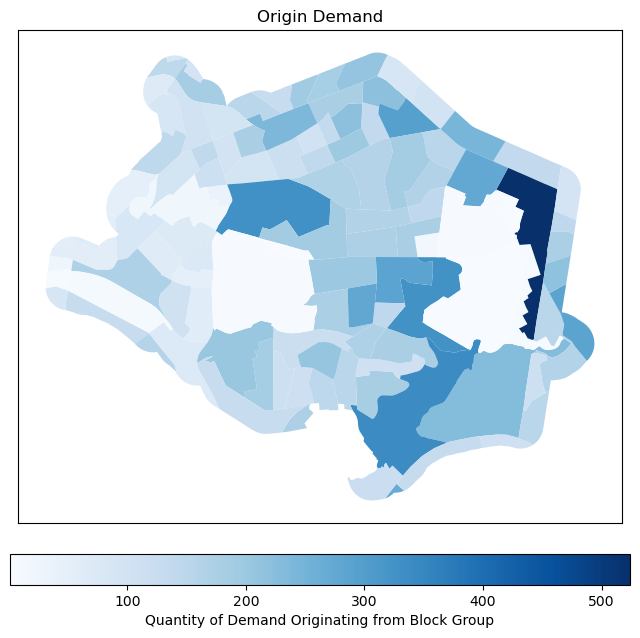

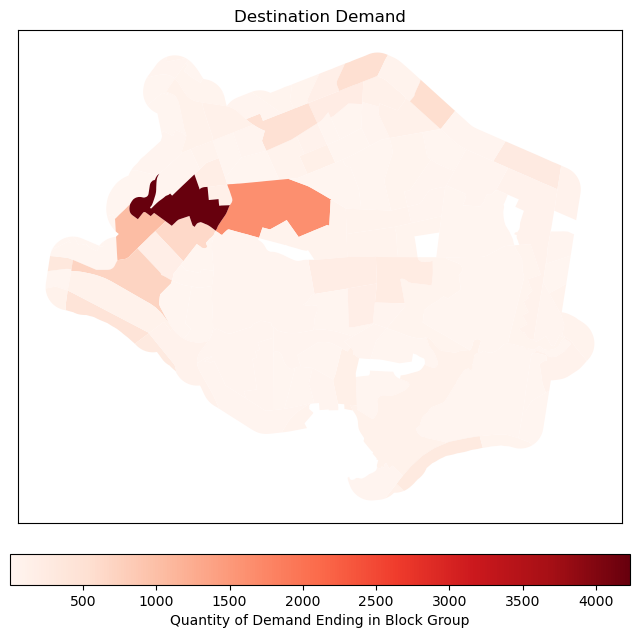

In [39]:
import matplotlib.pyplot as plt
org_demand_gdf = shape.merge(org_demand, how='right', on='GEOID')
dst_demand_gdf = shape.merge(dst_demand, how='right', on='GEOID')

# Plot the origin demand GeoDataFrame
fig, ax = plt.subplots(figsize=(8, 8))
org_demand_gdf.plot(column='S000', legend=True, cmap='Blues', legend_kwds={'label': 'Quantity of Demand Originating from Block Group', 'orientation':'horizontal', 'pad':0.05}, ax=ax)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
plt.title('Origin Demand')
plt.show()

# Plot the destination demand GeoDataFrame
fig, ax = plt.subplots(figsize=(8, 8))
dst_demand_gdf.plot(column='S000', legend=True, cmap='Reds', legend_kwds={'label': 'Quantity of Demand Ending in Block Group', 'orientation':'horizontal', 'pad':0.05}, ax=ax)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
plt.title('Destination Demand')
plt.show()